## 📄 SVRegression : Healthcare Insurance DataSet
---

**Veri Seti Hakkında:**

> Bu veri seti; kişisel özellikler (yaş, cinsiyet, VKİ, aile büyüklüğü, sigara içme alışkanlıkları), coğrafi faktörler ve bunların sağlık sigortası ücretleri üzerindeki etkisine dair bilgiler içermektedir. Veri seti, bu özelliklerin sigorta maliyetlerini nasıl etkilediğini incelemek ve sağlık harcamalarını tahmin etmeye yönelik öngörücü modeller geliştirmek için kullanılabilir.

* **Yaş:** Sigortalı kişinin yaşı.
* **Cinsiyet:** Sigortalının cinsiyeti (erkek veya kadın).
* **BMI (Vücut Kitle İndeksi):** Boy ve kiloya dayalı bir vücut yağı ölçümü.
* **Çocuklar:** Sigorta kapsamındaki bakmakla yükümlü olunan kişi sayısı.
* **Sigara İçen:** Sigortalının sigara kullanıp kullanmadığı (evet veya hayır).
* **Bölge:** Sigorta kapsamının geçerli olduğu coğrafi alan.
* **Masraflar:** Sigortalı kişinin karşılaştığı sağlık sigortası maliyetleri.

### 1. Kütüphanelerin Yüklenmesi ve Veriye İlk Bakış
> Standart veri işleme, görselleştirme ve modelleme kütüphanelerimizi içe aktarıyoruz.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error ,r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 2. Keşifsel Veri Analizi (EDA)

> Makine öğrenimi modellerini kurmadan önce verinin karakteristiğini anlamak kritik öneme sahiptir. Özellikle hedef değişkenimiz olan **charges'ın** dağılımına ve maliyetleri en çok artıran faktörlere bakmalıyız.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

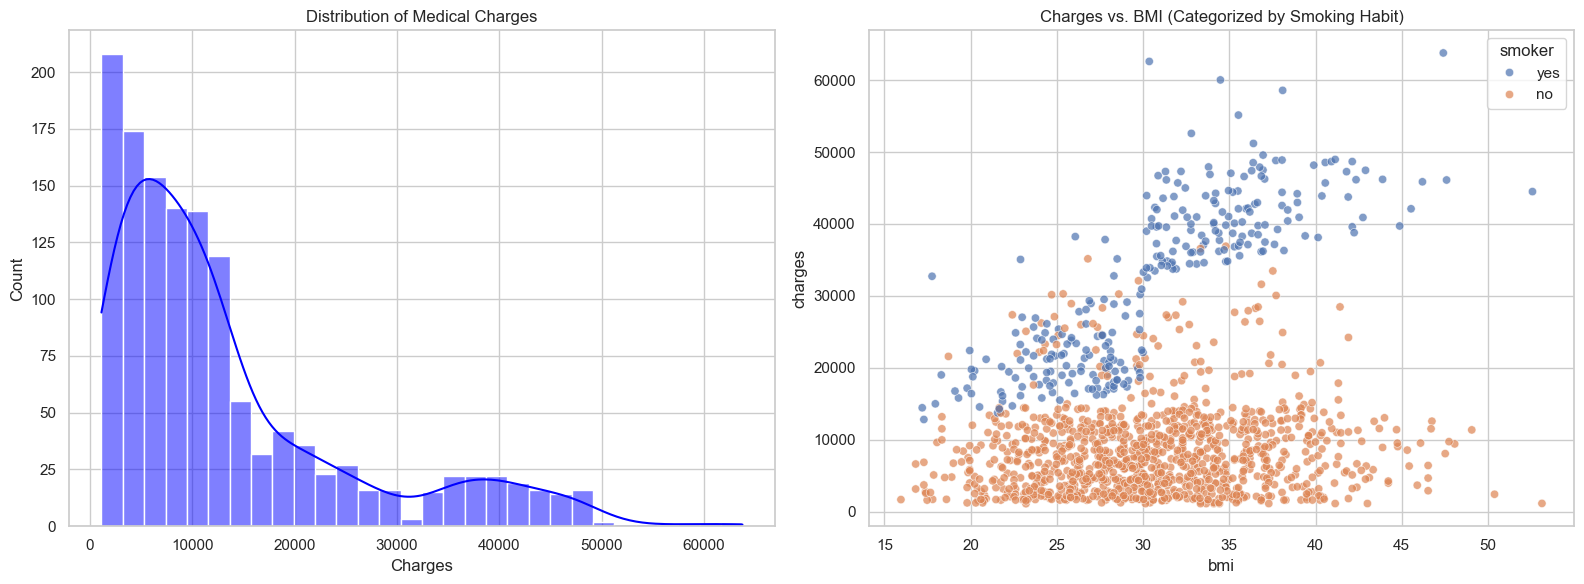

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hedef Değişken Dağılımı
sns.histplot(df['charges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Medical Charges')
axes[0].set_xlabel('Charges')

# Smoker ve BMI Etkileşimi
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=axes[1])
axes[1].set_title('Charges vs. BMI (Categorized by Smoking Habit)')

plt.tight_layout()
plt.show()

### 3. Veri Ön İşleme (Data Preprocessing)
> Kategorik değişkenleri makine öğrenimi modeline uygun hale getirmek için One-Hot Encoding uyguluyoruz. Dummy Variable Trap riskini önlemek adına drop_first=True kullanıyoruz.

In [7]:
# Kategorik değişkenlerin dönüştürülmesi
df = pd.get_dummies(data = df , columns=["region","smoker","sex"],drop_first=True ,dtype=int)

In [8]:
df.head()

,age,bmi,children,charges,region_northwest,region_southeast,region_southwest,smoker_yes,sex_male
0,19,27.900,0,16884.92400,0,0,1,1,0
1,18,33.770,1,1725.55230,0,1,0,0,1
2,28,33.000,3,4449.46200,0,1,0,0,1
3,33,22.705,0,21984.47061,1,0,0,0,1
4,32,28.880,0,3866.85520,1,0,0,0,1


In [9]:
X = df.drop("charges",axis=1)
y = df["charges"]

In [10]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

### 4. Ölçeklendirme (Feature & Target Scaling)
>Önemli Not: SVR, mesafe tabanlı bir algoritmadır ve değişkenlerin ölçeğine karşı son derece hassastır. Sadece bağımsız değişkenleri ($X$) değil, aynı zamanda sağa çarpık ve büyük değerlere sahip olan hedef değişkeni ($y$) de ele almalıyız. Bu projede hedef değişkene Logaritmik Dönüşüm ($\log(1+x)$) uygulayarak modeli eğiteceğiz.

In [11]:
# Bağımsız değişkenlerin ölçeklendirilmesi
scaler = StandardScaler()

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Hedef değişkenin logaritmik dönüşümü (Skewsness'i azaltmak için)
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

### 5. Model Kurulumu ve Hiperparametre Optimizasyonu
> Artık hedef değişken logaritmik bir düzlemde olduğu için $\epsilon=0.1$ ve $C$ değerleri çok daha anlamlı hale geldi. Çapraz doğrulama (Cross-Validation) ile en iyi parametreleri arıyoruz.

In [14]:
model = SVR()

In [15]:
# Hedef ölçeğimiz küçüldüğü için parametre uzayımızı buna göre ayarlıyoruz
param_grid = {
    "kernel" : ["linear" , "poly" , "rbf" , "sigmoid" ],
    "degree" : [2,3],            # Sadece poly kernel için
    "gamma"  : ["scale","auto"],
    "C"      : [0.1 , 1 , 10],
    "epsilon": [0.01, 0.1, 0.2]
}

In [16]:
grid = GridSearchCV(
    estimator=model,
    param_grid= param_grid,
    cv= 5,
    n_jobs=-1,
    verbose = 1,
    scoring='neg_mean_squared_error'
)

In [17]:
grid.fit(X_train_scaled, y_train_log)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'degree': [2, 3], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [18]:
print(f"En İyi Parametreler: {grid.best_params_}")

En İyi Parametreler: {'C': 1, 'degree': 2, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}


### 6. Model Değerlendirmesi ve Geri Dönüşüm
> Modelimiz tahminlerini logaritmik düzlemde yapıyor. Hata metriklerini (RMSE, MAE vb.) dolar ($) cinsinden yorumlayabilmek için ters dönüşüm (Inverse Transform - np.expm1) yapmamız zorunludur.

In [19]:
# Logaritmik tahminler
log_preds = grid.predict(X_test_scaled)

In [20]:
# Tahminleri orijinal düzleme (Dolar) geri çevirme
best_preds = np.expm1(log_preds)

In [21]:
rmse = np.sqrt(mean_squared_error(y_test, best_preds))
mae = mean_absolute_error(y_test, best_preds)
r2 = r2_score(y_test, best_preds)

In [22]:
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

Mean Absolute Error (MAE): $2,242.77
Root Mean Squared Error (RMSE): $4,995.16
R-squared (R2) Score: 0.8393


### 7. Model Performansının Görselleştirilmesi
> Sadece sayılara güvenmek yerine, modelimizin nerede yanıldığını (Residuals) görmek için tahmin vs gerçek değer grafiklerini çizdiriyoruz.

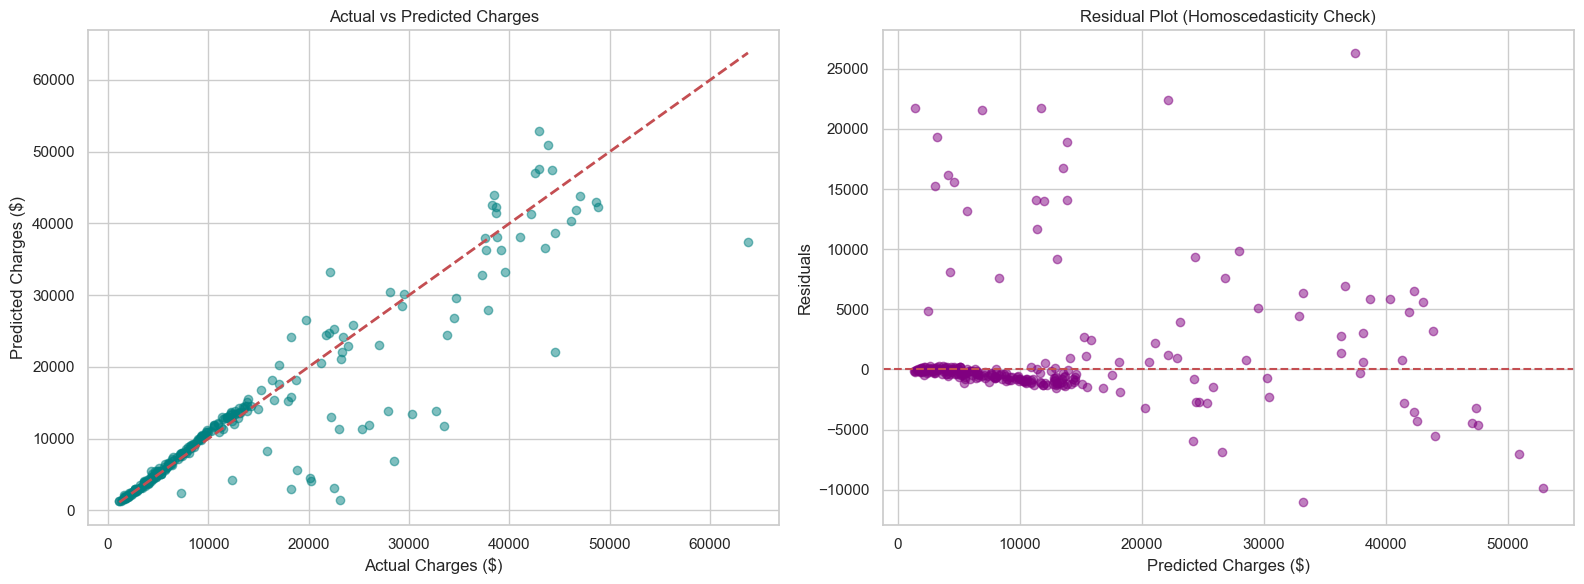

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gerçek vs Tahmin Edilen
axes[0].scatter(y_test, best_preds, alpha=0.5, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title('Actual vs Predicted Charges')

# Artık (Residual) Analizi
residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.5, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Charges ($)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot (Homoscedasticity Check)')

plt.tight_layout()
plt.show()

**Sonuç:** SVR modelinin tahmin performansını incelendiğimizde, logaritmik dönüşüm uygulamasının modelin uç değerleri (outliers) kavramasındaki başarısını büyük ölçüde artırdığı gözlemlenmiştir. Residual plot incelendiğinde, hataların 0 etrafında rastgele dağılım eğilimi göstermesi, kurduğumuz regresyon varsayımlarının büyük ölçüde korunduğunu işaret etmektedir.